In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

In [3]:
from matplotlib.ticker import ScalarFormatter

from scipy.stats import powerlaw


from scipy.interpolate import interp1d

In [4]:
import dsharp_opac as do
%matplotlib inline

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


## Band Wavelength and Colours

In [5]:
band1_color = "#f63fe3"
band3_color = "#2321f6"
band7_color = "#086608"
band10_color = "#fb0d0d"

red = band10_color
green = band7_color
blue = band3_color
pink = band1_color

band_colors = [band1_color, band3_color, band7_color, band10_color]

In [6]:
lambda_band1_micron  = 7.0  * 1000  # mm to microns
lambda_band3_micron  = 3.1  * 1000  # mm to microns
lambda_band7_micron  = 0.87 * 1000  # mm to microns
lambda_band10_micron = 0.34 * 1000  # mm to microns

lambda_bands_micron = [lambda_band1_micron, lambda_band3_micron, lambda_band7_micron, lambda_band10_micron]
lambda_bands_cm = micron_to_cm(lambda_bands_micron)

## DSHARP

Load the standard DSHARP dust mixture optical constants (oc) and density (rho_s)

In [7]:
oc, rho_g_cm3 = do.get_dsharp_mix()

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |


## Kataoka et al. 2015, Figure 1

In [8]:
logwave_vals = np.linspace(0, 4, 5000)
lambda_micron_fig1 = 10**logwave_vals

lambda_cm_fig1 = micron_to_cm(lambda_micron_fig1)

print(rf'Wavelength ranges from:')
print(rf"min: {np.min(lambda_micron_fig1)} microns")
print(rf"max: {np.max(lambda_micron_fig1)} microns")

Wavelength ranges from:
min: 1.0 microns
max: 10000.0 microns


In [9]:
a_max_micron_fig1 = [1, 100]
a_max_cm_fig1 = micron_to_cm(a_max_micron_fig1)

In [10]:
res_fig1 = do.get_opacities(a_max_cm_fig1, lambda_cm_fig1, rho_g_cm3 , oc, extrapolate_large_grains=False, n_angle=100)

k_abs_fig1 = res_fig1['k_abs']
k_sca_fig1 = res_fig1['k_sca']
S1_fig1    = res_fig1['S1']
S2_fig1    = res_fig1['S2']
theta_fig1 = res_fig1['theta']

Mie ... Done!


(0.001, 100000.0)

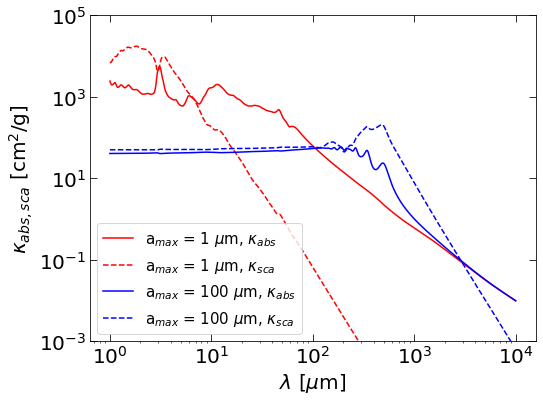

In [11]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(lambda_micron_fig1,
        k_abs_fig1[0],
        color = 'red',
        ls = '-',
        label = 'a$_{max}$ = 1 $\mu$m, $\kappa_{abs}$')

ax.plot(lambda_micron_fig1,
        k_sca_fig1[0],
        color = 'red',
        ls = '--',
        label = 'a$_{max}$ = 1 $\mu$m, $\kappa_{sca}$')

ax.plot(lambda_micron_fig1,
        k_abs_fig1[1],
        color = 'blue',
        ls = '-',
        label = 'a$_{max}$ = 100 $\mu$m, $\kappa_{abs}$')

ax.plot(lambda_micron_fig1,
        k_sca_fig1[1],
        color = 'blue',
        ls = '--',
        label = 'a$_{max}$ = 100 $\mu$m, $\kappa_{sca}$')

# Add axis labels
ax.set_xlabel('$\lambda$ [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('$\kappa_{abs, sca}$ [cm$^2$/g]', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

ax.legend(loc = 'lower left',
          fontsize = legend_text_fs)

# Make axes log if needed
ax.set_xscale('log')
ax.set_yscale('log')

# Set axis limits
# ax.setxlim()
ax.set_ylim(10e-4, 10e4)

## Kataoka et al. 2015, Figure 2

In [12]:
# From Kataoka et 1l, 2015 the grain sizes they are showing are 10 micron, 100 micron, 1 mm and 1 cm
fig2_labels = ['10 $\mu$m', '100 $\mu$m', '1 mm', '1 cm']

a_max_micron_fig2 = [10, 100, 1000, 10000]
a_max_cm_fig2 = micron_to_cm(a_max_micron_fig2)

In [13]:
a_min = 0.005e-4  # 0.05 micron in cm
a_grid = np.logspace(np.log10(a_min), np.log10(max(a_max_cm_fig2)), 500)

In [14]:
mass_grams_fig2 = calculate_grain_mass(a_max_cm_fig2, rho_g_cm3, "cm")

In [15]:
lambda_micron_fig2 = [lambda_band3_micron, lambda_band7_micron]
lambda_cm_fig2 = micron_to_cm(lambda_micron_fig2)

print('We are going to be using lambda values of:')

for lam_cm in lambda_cm_fig2:
    print(rf'{lam_cm:.3f} cm')

We are going to be using lambda values of:
0.310 cm
0.087 cm


In [16]:
# ---- a grid for grain distribution ----
a_dist_fig2 = np.logspace(np.log10(1e-4), np.log10(1e-1), 200)  # cm
distri_template = a_dist_fig2**0.5

In [17]:
mass_grams_fig2 = calculate_grain_mass(a_dist_fig2, rho_g_cm3, "cm")

In [18]:
# ---- Opacity and Mueller matrix ----
res = do.get_opacities(a_dist_fig2, lambda_cm_fig2, rho_g_cm3, oc, extrapolate_large_grains=False, n_angle=100)
k_abs, k_sca = res['k_abs'], res['k_sca']
S1, S2 = res['S1'], res['S2']
theta = res['theta']  # degrees

zscat = do.calculate_mueller_matrix(lambda_cm_fig2, mass_grams_fig2 , S1, S2, theta=theta, k_sca=k_sca)['zscat']

Mie ... Done!


In [19]:
# ---- a_max values for Fig 2 ----
a_max_micron_fig2 = [10, 100, 1000, 10000]
a_max_cm_fig2 = micron_to_cm(a_max_micron_fig2)
fig2_labels = ['10 $\mu$m', '100 $\mu$m', '1 mm', '1 cm']

In [20]:
scatt_angles_deg = np.linspace(0, 180, 5000)

In [21]:
# ---- Initialize ----
Z11eff = np.zeros((len(a_max_cm_fig2), len(lambda_cm_fig2), len(scatt_angles_deg)))
Z12eff = np.zeros_like(Z11eff)
omega = np.zeros((len(a_max_cm_fig2), len(lambda_cm_fig2)))

# ---- Loop over a_max ----
for ia, amax in enumerate(a_max_cm_fig2):
    distri = distri_template.copy()
    distri[a_dist_fig2 > amax] = 0
    distri /= distri.sum()

    for iw in range(len(lambda_cm_fig2)):
        z11_avg = np.sum(zscat[:, iw, :, 0] * distri[:, None], axis=0)
        z12_avg = np.sum(zscat[:, iw, :, 1] * distri[:, None], axis=0)

        f_z11 = interp1d(theta, z11_avg, kind='linear', bounds_error=False, fill_value="extrapolate")
        f_z12 = interp1d(theta, z12_avg, kind='linear', bounds_error=False, fill_value="extrapolate")

        Z11eff[ia, iw, :] = f_z11(scatt_angles_deg)
        Z12eff[ia, iw, :] = f_z12(scatt_angles_deg)

        k_a = np.sum(k_abs[:, iw] * distri)
        k_s = np.sum(k_sca[:, iw] * distri)
        omega[ia, iw] = k_s / (k_a + k_s)

In [22]:
P_eff = -Z12eff / Z11eff

# Extract for each band
P_band3_fig2 = P_eff[:, 0, :]  # 3.1 mm
P_band7_fig2 = P_eff[:, 1, :]  # 870 μm

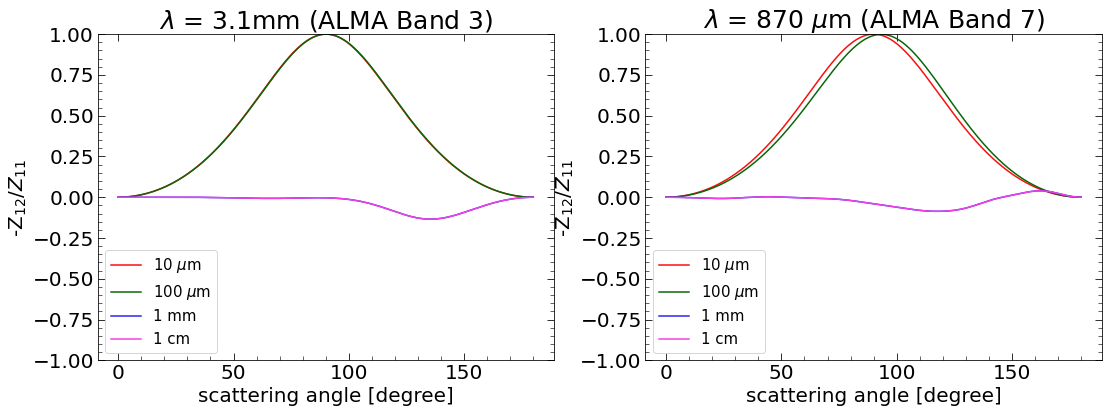

In [23]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Plot on the left
fig2_colors = [red, green, blue, pink]

for i in range(4):
    ax[0].plot(scatt_angles_deg, P_band3_fig2[i], color = fig2_colors[i], label = fig2_labels[i])
    ax[1].plot(scatt_angles_deg, P_band7_fig2[i], color = fig2_colors[i], label = fig2_labels[i])

# Add titles
ax[0].set_title('$\lambda$ = 3.1mm (ALMA Band 3)', fontsize = title_fs)
ax[1].set_title('$\lambda$ = 870 $\mu$m (ALMA Band 7)', fontsize = title_fs)

# Adjust ticks
for i in range(2):
    # Set axis labels
    ax[i].set_ylabel('-Z$_{12}/Z_{11}$', fontsize = axis_label_fs)
    ax[i].set_xlabel('scattering angle [degree]', fontsize = axis_label_fs)
    
    # Axis ticks
    ax[i].minorticks_on()
    
    ax[i].tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)


    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    # Add a legend
    ax[i].legend(fontsize = legend_text_fs, loc = 'lower left')
    
    # Set y-lim
    ax[i].set_ylim(-1, 1)


## Kataoka et al. 2015, Figure 3

The x-axis of Figures 3 and 4 is maximum grain size in cm, ranging from 0.001 to 1 cm

In [24]:
a_max_cm = np.logspace(-3, 0, 100)

print(rf'The lower bound of a_max is: {np.min(a_max_cm)} cm')
print(rf'The upper bound of a_max is: {np.max(a_max_cm)} cm')

The lower bound of a_max is: 0.001 cm
The upper bound of a_max is: 1.0 cm


In [25]:
mass_grams = calculate_grain_mass(a_max_cm, rho_g_cm3, "cm")

In [26]:
print('We are going to be using lambda values of:')

for lam_cm in lambda_bands_cm:
    print(rf'{lam_cm:.3f} cm')

We are going to be using lambda values of:
0.700 cm
0.310 cm
0.087 cm
0.034 cm


In [27]:
res = do.get_opacities(a_max_cm, lambda_bands_cm, rho_g_cm3 , oc, extrapolate_large_grains=False, n_angle=100)

k_abs = res['k_abs']
k_sca = res['k_sca']
S1    = res['S1']
S2    = res['S2']
theta = res['theta']

# index where theta = 90 degree

i90 = theta.searchsorted(90)

Mie ... Done!


In [28]:
zscat = do.calculate_mueller_matrix(lambda_bands_cm, mass_grams, S1, S2, theta=theta, k_sca=k_sca)['zscat']

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 47%: above error tolerance
  warnings.warn(


In [29]:
# Initialize arrays for results
Z11eff = np.zeros([len(a_max_cm), len(lambda_bands_cm)])
Z12eff = np.zeros_like(Z11eff)
omega = np.zeros_like(Z11eff)

# Loop over maximum grain sizes
for ia, amax in enumerate(a_max_cm):
    # Create normalized MRN distribution truncated at current max grain size
    distri = a_max_cm**0.5
    distri[a_max_cm > amax] = 0
    distri /= distri.sum()
    
    # Average scattering matrix elements at 90 deg scattering angle
    Z11eff[ia] = np.sum(zscat[:, :, i90, 0] * distri[:, None], axis=0)
    Z12eff[ia] = np.sum(zscat[:, :, i90, 1] * distri[:, None], axis=0)
    
    # Average opacities to get average albedo omega
    k_a = np.sum(k_abs * distri[:, None], axis=0)
    k_s = np.sum(k_sca * distri[:, None], axis=0)
    omega[ia] = k_s / (k_a + k_s)

In [30]:
omega_band1 = omega[:, 0]
omega_band3 = omega[:, 1]
omega_band7 = omega[:, 2]
omega_band10 = omega[:, 3]

In [31]:
# Calculate polarization fraction at 90 degree
P = np.abs(Z12eff / Z11eff)

# Extract polarization fractions at individual bands:
P_band1 = P[:, 0]  # First wavelength (e.g., Band 1)
P_band3 = P[:, 1]  # Second wavelength (e.g., Band 3)
P_band7 = P[:, 2]  # Third wavelength (e.g., Band 7)
P_band10 = P[:, 3] # Fourth wavelength (e.g., Band 10)

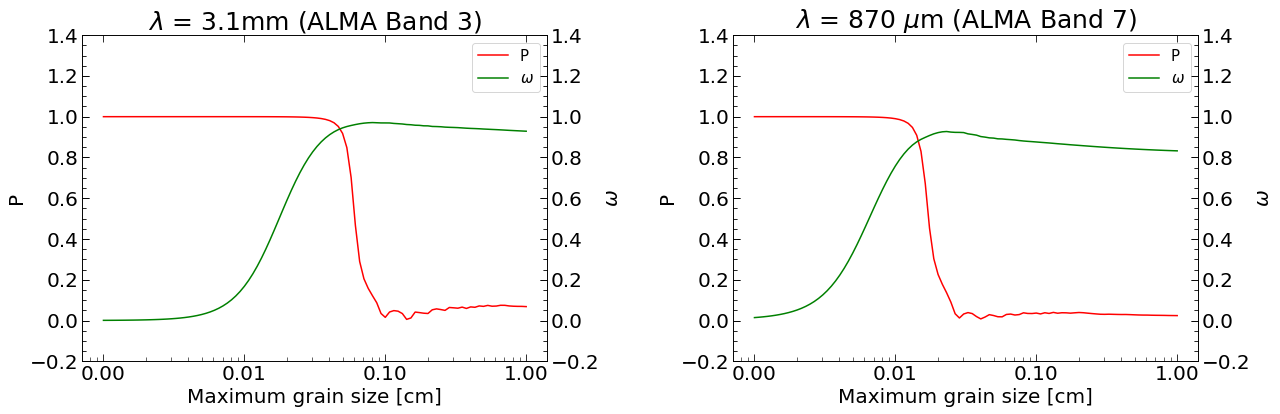

In [32]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize=(20, 6))  # Wider figure for spacing

# Create secondary y-axes
ax2_0 = ax[0].twinx()
ax2_1 = ax[1].twinx()

# Plot on the left
line_P3,     = ax[0].plot(a_max_cm, P_band3, color='red', label='P')
line_omega3, = ax2_0.plot(a_max_cm, omega_band3, color='green', label=r'$\omega$')

# Plot on the right
line_P7,     = ax[1].plot(a_max_cm, P_band7, color='red', label='P')
line_omega7, = ax2_1.plot(a_max_cm, omega_band7, color='green', label=r'$\omega$')

# Titles
ax[0].set_title(r'$\lambda$ = 3.1mm (ALMA Band 3)', fontsize=title_fs)
ax[1].set_title(r'$\lambda$ = 870 $\mu$m (ALMA Band 7)', fontsize=title_fs)

# X-axis labels
ax[0].set_xlabel('Maximum grain size [cm]', fontsize=axis_label_fs)
ax[1].set_xlabel('Maximum grain size [cm]', fontsize=axis_label_fs)

# Y-axis labels
ax[0].set_ylabel('P', fontsize=axis_label_fs)
ax[1].set_ylabel('P', fontsize=axis_label_fs)
ax2_0.set_ylabel(r'$\omega$', fontsize=axis_label_fs)
ax2_1.set_ylabel(r'$\omega$', fontsize=axis_label_fs)

# Ticks
for a in [ax[0], ax[1], ax2_0, ax2_1]:
    a.minorticks_on()
    a.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    a.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
    a.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    a.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    a.set_ylim(-0.2, 1.4)
# Only lines are colored; axis ticks remain default
# (Do NOT color ax2 ticks to green)

# Single legend per subplot
ax[0].legend(handles = [line_P3, line_omega3], fontsize=legend_text_fs, loc='upper right')
ax[1].legend(handles = [line_P7, line_omega7], fontsize=legend_text_fs, loc='upper right')

# Add spacing between subplots
plt.subplots_adjust(wspace=0.4)

for i in range(2):
    # Make axes log if needed
    ax[i].set_xscale('log')
#     ax[i].set_yscale('log')

    # Remove scientific notation from x-axis
    ax[i].xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax[i].ticklabel_format(style='plain', axis='x')
    

## Kataoka et al. 2015, Figure 4

In [33]:
P_times_omega_band1  = P_band1  * omega_band1
P_times_omega_band3  = P_band3  * omega_band3
P_times_omega_band7  = P_band7  * omega_band7
P_times_omega_band10 = P_band10 * omega_band10

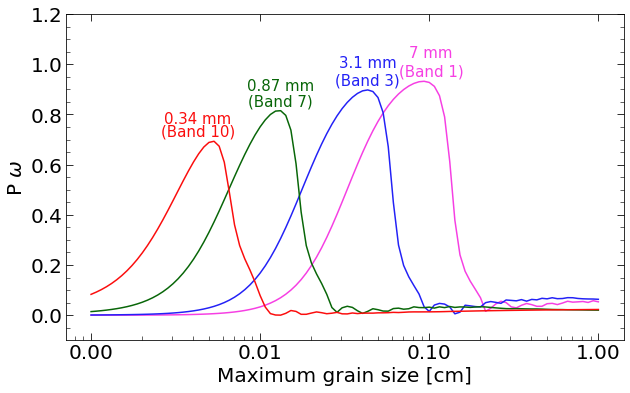

In [34]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(a_max_cm,
        P_times_omega_band1,
        color = band1_color,
        ls = '-',
        label = '7 mm (Band 1)')

ax.plot(a_max_cm,
        P_times_omega_band3,
        color = band3_color,
        ls = '-',
        label = '3.1 mm (Band 3)')


ax.plot(a_max_cm,
        P_times_omega_band7,
        color = band7_color,
        ls = '-',
        label = '0.87 mm (Band 7)')


ax.plot(a_max_cm,
        P_times_omega_band10,
        color = band10_color,
        ls = '-',
        label = '0.34 mm (Band 10)')


# Add axis labels
ax.set_xlabel('Maximum grain size [cm]', fontsize=axis_label_fs)
ax.set_ylabel('P $\omega$', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)



# Make axes log if needed
ax.set_xscale('log')
# ax.set_yscale('log')

# Remove scientific notation from x-axis
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')

ax.set_ylim(-0.1, 1.2)


# Add labels to each line
y_vals = [P_times_omega_band1, P_times_omega_band3, P_times_omega_band7, P_times_omega_band10]
top_label = ['7 mm', '3.1 mm', '0.87 mm', '0.34 mm']
bottom_label = ['(Band 1)', '(Band 3)', '(Band 7)', '(Band 10)']
fs = 15
x_offset = [1.1, 1, 1, 0.8]

for i in range(4):
    y_loc = np.max(y_vals[i])
    idx = np.argmax(y_vals[i])
    x_loc = a_max_cm[idx]

    # Offset value can be tuned depending on your data scale
    ax.text(x_loc * x_offset[i], y_loc * 1.1,  # top label slightly above peak
            top_label[i],
            color=band_colors[i],
            fontsize=fs,
            ha='center')

    ax.text(x_loc * x_offset[i], y_loc + 0.02,  # bottom label at peak
            bottom_label[i],
            color=band_colors[i],
            fontsize=fs,
            ha='center')